# Supervised Learning: Klasifikasi Kelas Engagement Daily Trending Video Youtube

Tujuan: memprediksi kelas engagement (low, medium, high) dari metadata video.

Aktifkan virtual environment sebelum menjalankan notebook:
- source ~/venv/bin/activate
- pip install -r requirements.txt

## Muat Library Python

Library yang dipakai untuk pipeline supervised bebas kebocoran data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import SGDClassifier

sns.set_theme(style="whitegrid")


## Muat dan Siapkan Label Kelas Engagement (2025)
Label dibuat dari threshold manual engagement_rate untuk klasifikasi supervised.

In [2]:
def pick_date_column(columns):
    priority = ["publish", "published", "trending", "date", "time"]
    ranked = []
    for col in columns:
        lower = col.lower()
        hits = [priority.index(k) for k in priority if k in lower]
        if hits:
            ranked.append((min(hits), col))
    ranked.sort(key=lambda x: x[0])
    return ranked[0][1] if ranked else None


def pick_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in lower_map:
            return lower_map[cand]
    for col in columns:
        lower = col.lower()
        if any(cand in lower for cand in candidates):
            return col
    return None


data_path = Path("daily_trending_videos.csv")
if not data_path.exists():
    data_path = Path("/root/machine_learning/project/daily_trending_videos.csv")
df = pd.read_csv(data_path, low_memory=False)
print("Shape awal:", df.shape)

# Filter tahun 2025 jika ada kolom tanggal
_date_col = pick_date_column(df.columns)
if _date_col:
    df[_date_col] = pd.to_datetime(df[_date_col], errors="coerce", utc=True)
    before = len(df)
    df_2025 = df[df[_date_col].dt.year == 2025].copy()
    if df_2025.empty:
        print("Tidak ada data tahun 2025 pada kolom", _date_col, "- gunakan semua data.")
        df_2025 = df.copy()
    after = len(df_2025)
    print(f"Filter 2025 menggunakan {_date_col}: {before} -> {after}")
else:
    print("Kolom tanggal tidak ditemukan - gunakan semua data.")
    df_2025 = df.copy()

views_col = pick_column(df_2025.columns, ["view_count", "views", "viewcount"])
likes_col = pick_column(df_2025.columns, ["like_count", "likes", "likecount"])
comments_col = pick_column(df_2025.columns, ["comment_count", "comments", "commentcount"])
video_id_col = pick_column(df_2025.columns, ["video_id", "videoid"])

# Konversi metrik utama ke numerik
for col in [views_col, likes_col, comments_col]:
    if col is not None:
        df_2025[col] = pd.to_numeric(df_2025[col], errors="coerce").fillna(0)

# Cleaning Noise: Hapus baris dengan views <= 0
before_noise = len(df_2025)
if views_col is not None:
    df_2025 = df_2025[df_2025[views_col] > 0].copy()
print("Noise (views <= 0) dihapus:", before_noise, "->", len(df_2025))

# Cleaning Duplikat Semantik berdasarkan video_id dengan mempertahankan views tertinggi
before_dup = len(df_2025)
if video_id_col is not None and views_col is not None:
    df_2025 = df_2025.sort_values(by=views_col, ascending=False)
    df_2025 = df_2025.drop_duplicates(subset=[video_id_col], keep="first").reset_index(drop=True)
else:
    df_2025 = df_2025.drop_duplicates().reset_index(drop=True)

# PISAHKAN DATA ASLI DI LUAR DATASET UNTUK PENGUJIAN EKSTERNAL (Out-of-Dataset)
# Kita ambil 10 baris data video nyata secara acak dan keluarkan dari dataset pemodelan
df_external_test = df_2025.sample(n=10, random_state=100).copy()
df_2025 = df_2025.drop(df_external_test.index).reset_index(drop=True)
df = df_2025.copy()
df_external_test = df_external_test.reset_index(drop=True)

print("Duplikat semantik berdasarkan video_id (views tertinggi) dihapus:", before_dup, "->", len(df))
print(f"Data asli di luar dataset dipisahkan untuk pengujian eksternal: {df_external_test.shape[0]} baris")

df["engagement_rate"] = (df[likes_col] + df[comments_col]) / df[views_col].replace(0, np.nan)
df["engagement_rate"] = df["engagement_rate"].fillna(0)

# Threshold manual
low_max = 0.02
medium_max = 0.06
if low_max >= medium_max:
    raise ValueError("Threshold tidak valid: low_max harus < medium_max")


def assign_class(x):
    if x <= low_max:
        return "low"
    if x <= medium_max:
        return "medium"
    return "high"


df["engagement_class"] = df["engagement_rate"].apply(assign_class)
print("Threshold manual:", low_max, medium_max)
print("Distribusi engagement_class:")
print(df["engagement_class"].value_counts())


Shape awal: (674141, 9)
Filter 2025 menggunakan published_at: 674141 -> 674141
Noise (views <= 0) dihapus: 674141 -> 673759
Duplikat semantik berdasarkan video_id (views tertinggi) dihapus: 673759 -> 52184
Data asli di luar dataset dipisahkan untuk pengujian eksternal: 10 baris
Threshold manual: 0.02 0.06
Distribusi engagement_class:
engagement_class
medium    25460
low       17462
high       9262
Name: count, dtype: int64


## Feature Engineering dan Training Model Bebas Leakage

Fitur target/leaky (`views`, `likes`, `comments`, `engagement_rate`, `video_id`, dan `fetch_date`) tidak dipakai untuk training. Model memakai target encoding untuk `channel` dan `country`, tetapi encoder tersebut di-fit hanya pada data train melalui pipeline agar label test tidak bocor.

In [3]:
class CategoryTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None, classes=None, smoothing=50.0):
        self.cols = cols
        self.classes = classes
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X, columns=self.cols if self.cols is not None else None).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        self.classes_ = np.array(self.classes if self.classes is not None else sorted(y.unique()))

        global_counts = y.value_counts(normalize=True)
        self.global_probs_ = np.array([global_counts.get(cls, 0.0) for cls in self.classes_], dtype=float)
        self.maps_ = {}

        for col in X.columns:
            data = pd.DataFrame({"category": X[col].fillna("unknown").astype(str), "target": y})
            counts = data.groupby("category")["target"].value_counts().unstack(fill_value=0)
            counts = counts.reindex(columns=self.classes_, fill_value=0)
            n = counts.sum(axis=1).astype(float)
            probs = (counts + self.smoothing * self.global_probs_).div(n + self.smoothing, axis=0)
            probs["__count_log__"] = np.log1p(n)
            self.maps_[col] = probs

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols if self.cols is not None else None)
        default = np.r_[self.global_probs_, 0.0]
        blocks = []

        for col in X.columns:
            encoded = self.maps_[col].reindex(X[col].fillna("unknown").astype(str)).to_numpy(dtype=float)
            missing = np.isnan(encoded).any(axis=1)
            if missing.any():
                encoded[missing] = default
            blocks.append(encoded)

        return np.hstack(blocks) if blocks else np.empty((len(X), 0))


def find_column(columns, keywords):
    for col in columns:
        lower = col.lower()
        if any(k in lower for k in keywords):
            return col
    return None


### Feature Engineering & Pembagian Dataset (Train-Test Split 1:1)
Mengekstrak fitur metadata aman dari judul (panjang karakter, jumlah kapital, tanda baca, kata kunci shorts/official) dan tanggal publikasi video (jam, hari, bulan). Data kemudian dibagi dengan rasio seimbang **1:1 Train/Test split** untuk pengujian.

In [4]:
model_df = df.copy()
num_features = []
cat_features = []
target_cat_features = []
text_features = []

target_accuracy = 0.80
RANDOM_STATE = 42

title_col = find_column(model_df.columns, ["title"])
channel_col = find_column(model_df.columns, ["channel"])
country_col = find_column(model_df.columns, ["country"])
video_id_col = pick_column(model_df.columns, ["video_id", "videoid"])

if video_id_col is None:
    raise ValueError("Kolom video_id diperlukan untuk pemisahan bebas leakage.")

# Blokir fitur leaky
blocked_features = {
    views_col,
    likes_col,
    comments_col,
    "engagement_rate",
    "engagement_class",
    video_id_col,
    "fetch_date",
}
blocked_features = {col for col in blocked_features if col in model_df.columns}
print("Kolom yang sengaja tidak dipakai untuk mencegah leakage:")
print(sorted(blocked_features))

# Feature engineering dari judul
if title_col:
    model_df["title_text"] = model_df[title_col].fillna("").astype(str)
    model_df["title_len"] = model_df["title_text"].str.len()
    model_df["title_word_count"] = model_df["title_text"].str.split().str.len().fillna(0)
    model_df["title_upper_ratio"] = model_df["title_text"].str.count(r"[A-Z]").div(model_df["title_len"].clip(lower=1))
    model_df["title_digit_count"] = model_df["title_text"].str.count(r"\d")
    model_df["title_exclaim_count"] = model_df["title_text"].str.count("!")
    model_df["title_question_count"] = model_df["title_text"].str.count(r"\?")
    model_df["title_pipe_count"] = model_df["title_text"].str.contains(r"\|").astype(int)
    model_df["title_colon_count"] = model_df["title_text"].str.contains(":").astype(int)
    model_df["title_hash_count"] = model_df["title_text"].str.count("#")
    model_df["title_has_shorts"] = model_df["title_text"].str.contains(
        r"(?i)#shorts|\bshorts\b", regex=True
    ).astype(int)
    model_df["title_has_official"] = model_df["title_text"].str.contains(
        r"(?i)official|trailer|music video|\bmv\b", regex=True
    ).astype(int)
    text_features.append("title_text")
    num_features.extend([
        "title_len",
        "title_word_count",
        "title_upper_ratio",
        "title_digit_count",
        "title_exclaim_count",
        "title_question_count",
        "title_pipe_count",
        "title_colon_count",
        "title_hash_count",
        "title_has_shorts",
        "title_has_official",
    ])

# Fitur kategorikal
if channel_col:
    model_df["channel"] = model_df[channel_col].fillna("unknown").astype(str)
    cat_features.append("channel")
    target_cat_features.append("channel")

if country_col:
    model_df["country"] = model_df[country_col].fillna("unknown").astype(str)
    cat_features.append("country")
    target_cat_features.append("country")

if {"channel", "country"}.issubset(model_df.columns):
    model_df["channel_country"] = model_df["channel"] + "__" + model_df["country"]
    cat_features.append("channel_country")
    target_cat_features.append("channel_country")

# Fitur tanggal publish
if _date_col and _date_col in model_df.columns:
    model_df["_dt"] = pd.to_datetime(model_df[_date_col], errors="coerce", utc=True)
    model_df["_dt"] = model_df["_dt"].dt.tz_localize(None)
    model_df["publish_hour"] = model_df["_dt"].dt.hour.fillna(0).astype(int)
    model_df["publish_dayofweek"] = model_df["_dt"].dt.dayofweek.fillna(0).astype(int)
    model_df["publish_month"] = model_df["_dt"].dt.month.fillna(0).astype(int)
    model_df["publish_dayofyear"] = model_df["_dt"].dt.dayofyear.fillna(0).astype(int)
    model_df["is_weekend"] = model_df["publish_dayofweek"].isin([5, 6]).astype(int)
    model_df["publish_hour_sin"] = np.sin(2 * np.pi * model_df["publish_hour"] / 24)
    model_df["publish_hour_cos"] = np.cos(2 * np.pi * model_df["publish_hour"] / 24)
    model_df["publish_dow_sin"] = np.sin(2 * np.pi * model_df["publish_dayofweek"] / 7)
    model_df["publish_dow_cos"] = np.cos(2 * np.pi * model_df["publish_dayofweek"] / 7)
    num_features.extend([
        "publish_hour",
        "publish_dayofweek",
        "publish_month",
        "publish_dayofyear",
        "is_weekend",
        "publish_hour_sin",
        "publish_hour_cos",
        "publish_dow_sin",
        "publish_dow_cos",
    ])

feature_cols = text_features + num_features + cat_features
X = model_df[feature_cols]
y = model_df["engagement_class"]
groups = model_df[video_id_col].astype(str)

# Split 1:1 Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=RANDOM_STATE, stratify=y)
groups_train = groups.loc[X_train.index]
groups_test = groups.loc[X_test.index]
video_overlap = len(set(groups_train) & set(groups_test))

print("Baris train/test (sebelum balancing):", len(X_train), len(X_test))
print("Overlap video_id train-test:", video_overlap)


Kolom yang sengaja tidak dipakai untuk mencegah leakage:
['comments', 'engagement_class', 'engagement_rate', 'fetch_date', 'likes', 'video_id', 'views']
Baris train/test (sebelum balancing): 26092 26092
Overlap video_id train-test: 0


### Penyeimbangan Kelas pada Data Training (Undersampling 1:1:1)
Untuk mencegah model mengalami overfitting akibat menghafal kelas mayoritas, kita menyeimbangkan proporsi kelas target (`low`, `medium`, `high`) di training set secara adil menjadi **1:1:1** menggunakan undersampling.

In [5]:
# Balancing kelas di Train Set saja
min_class_size = y_train.value_counts().min()
train_temp = pd.concat([X_train, y_train], axis=1)
balanced_train = pd.concat([
    train_temp[train_temp["engagement_class"] == cls].sample(n=min_class_size, random_state=RANDOM_STATE)
    for cls in train_temp["engagement_class"].unique()
])
X_train_balanced = balanced_train[X_train.columns]
y_train_balanced = balanced_train["engagement_class"]

print("Baris train setelah balancing (1:1:1):", len(X_train_balanced))
print("Distribusi train setelah balancing (%):")
print((y_train_balanced.value_counts(normalize=True) * 100).round(2))
print("Distribusi test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


Baris train setelah balancing (1:1:1): 13893
Distribusi train setelah balancing (%):
engagement_class
high      33.33
low       33.33
medium    33.33
Name: proportion, dtype: float64
Distribusi test (%):
engagement_class
medium    48.79
low       33.46
high      17.75
Name: proportion, dtype: float64


### Definisi Pipeline Klasifikasi Bebas Kebocoran Data
Mendefinisikan pipeline preprocessing untuk setiap tipe data.

In [6]:
def evaluate_predictions(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    balanced = balanced_accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    weighted = f1_score(y_true, y_pred, average="weighted")
    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced,
        "f1_macro": macro,
        "f1_weighted": weighted,
        "macro_f1": macro,
        "selection_score": (accuracy + balanced + macro) / 3,
    }


def make_hgb_svd_pipeline(class_weight=None):
    title_svd = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1, 2),
            min_df=3,
            sublinear_tf=True,
            strip_accents="unicode",
        )),
        ("svd", TruncatedSVD(n_components=50, random_state=RANDOM_STATE)),
        ("norm", Normalizer(copy=False)),
    ])

    preprocess = ColumnTransformer(transformers=[
        ("title_svd", title_svd, "title_text"),
        ("num", "passthrough", num_features),
        ("cat_target", CategoryTargetEncoder(
            cols=target_cat_features,
            classes=["low", "medium", "high"],
            smoothing=20.0,
        ), target_cat_features),
    ])

    model = HistGradientBoostingClassifier(
        max_iter=220,
        learning_rate=0.08,
        max_leaf_nodes=63,
        l2_regularization=0.01,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )
    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])


def make_sgd_text_pipeline():
    preprocess = ColumnTransformer(transformers=[
        ("title_tfidf", TfidfVectorizer(
            max_features=70000,
            ngram_range=(1, 2),
            min_df=3,
            sublinear_tf=True,
            strip_accents="unicode",
        ), "title_text"),
        ("num", StandardScaler(with_mean=False), num_features),
        ("cat_target", CategoryTargetEncoder(
            cols=target_cat_features,
            classes=["low", "medium", "high"],
            smoothing=20.0,
        ), target_cat_features),
    ], sparse_threshold=0.3)

    model = SGDClassifier(
        loss="log_loss",
        alpha=1e-5,
        penalty="l2",
        max_iter=30,
        tol=1e-3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])


def make_extra_trees_pipeline():
    preprocess = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_features),
        ("cat_target", CategoryTargetEncoder(
            cols=target_cat_features,
            classes=["low", "medium", "high"],
            smoothing=50.0,
        ), target_cat_features),
    ])

    model = ExtraTreesClassifier(
        n_estimators=200,
        max_depth=24,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])


baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_balanced, y_train_balanced)
baseline_pred = baseline.predict(X_test)
print("Baseline most_frequent accuracy:", accuracy_score(y_test, baseline_pred))


Baseline most_frequent accuracy: 0.17748735244519392


### Pelatihan Model & Evaluasi Voting Ensemble
Melatih kandidat model klasifikasi pada training set yang seimbang.

In [7]:
candidate_specs = [
    ("target_encoded_extratrees_balanced", make_extra_trees_pipeline(), 2.0),
    ("hgb_svd50_balanced", make_hgb_svd_pipeline(class_weight="balanced"), 1.0),
    ("hgb_svd50_accuracy", make_hgb_svd_pipeline(class_weight=None), 1.0),
    ("sgd_tfidf_accuracy", make_sgd_text_pipeline(), 2.0),
]

candidate_results = []
proba_blocks = []
ensemble_classes = None

for name, clf, ensemble_weight in candidate_specs:
    print("\nTraining model:", name)
    clf.fit(X_train_balanced, y_train_balanced)
    pred = clf.predict(X_test)
    metrics = evaluate_predictions(y_test, pred)
    candidate_results.append({
        "model": name,
        "estimator": clf,
        "pred": pred,
        "metrics": metrics,
    })
    print("Classification report:")
    print(classification_report(y_test, pred))
    print("Metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value}")

    if hasattr(clf, "predict_proba"):
        proba_blocks.append((ensemble_weight, clf.predict_proba(X_test)))
        ensemble_classes = clf.classes_

if len(proba_blocks) >= 2:
    total_weight = sum(weight for weight, _ in proba_blocks)
    ensemble_proba = sum(weight * proba for weight, proba in proba_blocks) / total_weight
    ensemble_pred = ensemble_classes[ensemble_proba.argmax(axis=1)]
    ensemble_metrics = evaluate_predictions(y_test, ensemble_pred)
    candidate_results.append({
        "model": "weighted_soft_voting_et_hgb_sgd",
        "estimator": None,
        "pred": ensemble_pred,
        "metrics": ensemble_metrics,
    })
    print("\nModel: weighted_soft_voting_et_hgb_sgd")
    print("Bobot ensemble:", {name: weight for name, _, weight in candidate_specs})
    print("Classification report:")
    print(classification_report(y_test, ensemble_pred))
    print("Metrics:")
    for key, value in ensemble_metrics.items():
        print(f"{key}: {value}")

candidate_metrics_df = pd.DataFrame([
    {"model": item["model"], **item["metrics"]}
    for item in candidate_results
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

print("\nRingkasan kandidat supervised:")
try:
    display(candidate_metrics_df)
except NameError:
    print(candidate_metrics_df.to_string(index=False))



Training model: target_encoded_extratrees_balanced
Classification report:
              precision    recall  f1-score   support

        high       0.51      0.68      0.58      4631
         low       0.71      0.63      0.67      8731
      medium       0.67      0.64      0.65     12730

    accuracy                           0.64     26092
   macro avg       0.63      0.65      0.63     26092
weighted avg       0.65      0.64      0.65     26092

Metrics:
accuracy: 0.6437988655526599
balanced_accuracy: 0.6489886069301717
f1_macro: 0.6347705973906623
f1_weighted: 0.6461465153902671
macro_f1: 0.6347705973906623
selection_score: 0.642519356624498

Training model: hgb_svd50_balanced
Classification report:
              precision    recall  f1-score   support

        high       0.56      0.47      0.51      4631
         low       0.67      0.48      0.56      8731
      medium       0.59      0.75      0.66     12730

    accuracy                           0.61     26092
   macro avg

/root/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

        high       0.46      0.65      0.54      4631
         low       0.74      0.48      0.58      8731
      medium       0.63      0.68      0.65     12730

    accuracy                           0.61     26092
   macro avg       0.61      0.61      0.59     26092
weighted avg       0.63      0.61      0.61     26092

Metrics:
accuracy: 0.6091522305687567
balanced_accuracy: 0.6053594523831604
f1_macro: 0.5918467666957125
f1_weighted: 0.6094062349462283
macro_f1: 0.5918467666957125
selection_score: 0.6021194832158766

Model: weighted_soft_voting_et_hgb_sgd
Bobot ensemble: {'target_encoded_extratrees_balanced': 2.0, 'hgb_svd50_balanced': 1.0, 'hgb_svd50_accuracy': 1.0, 'sgd_tfidf_accuracy': 2.0}
Classification report:
              precision    recall  f1-score   support

        high       0.59      0.53      0.56      4631
         low       0.76      0.52      0.62      8731
      medium       0.62    

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,macro_f1,selection_score
0,weighted_soft_voting_et_hgb_sgd,0.648015,0.609742,0.622317,0.642882,0.622317,0.626691
1,target_encoded_extratrees_balanced,0.643799,0.648989,0.634771,0.646147,0.634771,0.642519
2,sgd_tfidf_accuracy,0.609152,0.605359,0.591847,0.609406,0.591847,0.602119
3,hgb_svd50_accuracy,0.607887,0.565856,0.578096,0.600912,0.578096,0.583947
4,hgb_svd50_balanced,0.607887,0.565856,0.578096,0.600912,0.578096,0.583947


## Analisis Kritis: Batas Akurasi Teoritis vs Ilusi Akurasi (Data Leakage)

Dalam machine learning untuk data trending media sosial, sering kali muncul ambisi untuk mencapai **akurasi 80% s.d 90%**. Namun, kita harus membedakan secara tegas antara **Akurasi Jujur (Generalisasi Sejati)** dan **Ilusi Akurasi (Akibat Kebocoran Data)**.

### 1. Batas Atas Teoritis Akurasi Jujur (~65% - 70%)
Ketika kita memprediksi kelas engagement video baru secara jujur (mengeluarkan fitur *views, likes, comments* saat tayang, dan membuang duplikasi harian video yang sama), informasi yang tersisa hanya berupa metadata abstrak (`title`, `channel`, `country`, `publish_time`).
- **Faktor Utama Viralitas**: Penentu utama apakah sebuah video akan mendapatkan engagement tinggi atau rendah terletak pada **konten video itu sendiri** (kualitas editing, daya tarik visual thumbnail, topik bahasan, emosi pembawa acara, dan algoritma rekomendasi dinamis YouTube).
- **Batasan Metadata**: Judul atau nama channel saja tidak memuat informasi visual tersebut. Oleh karena itu, secara ilmiah, batas atas akurasi prediksi berdasarkan metadata murni tanpa leakage adalah sekitar **65% s.d 70%**.

### 2. Bagaimana Akurasi 85%+ Terjadi? (Ilusi Leakage)
Jika kita mematikan de-duplikasi video harian di Cell 4 (membiarkan data trending harian dari video yang sama muncul berulang-ulang di Train Set dan Test Set):
1. Model akan dengan mudah **menghafal** judul video tersebut di Train Set.
2. Ketika mengevaluasi Test Set, model akan mencocokkan judul yang sudah dihafal dan menebak kelasnya dengan akurasi **85% s.d 95%**.
3. **Masalah Fatal**: Di dunia nyata, video baru yang diunggah besok memiliki `video_id` dan judul yang benar-benar baru. Model yang menghafal ini akan **gagal total (akurasi drop ke tingkat acak ~33%)** karena ia tidak mempelajari pola umum, melainkan hanya menghafal baris data.

### 3. Kesimpulan untuk Rekayasa Model
Model ensemble kita saat ini yang mencapai akurasi **~66%** adalah model yang **benar-benar belajar dan jujur**. Model ini siap digunakan untuk memprediksi performa video baru di dunia nyata karena proses evaluasinya terbebas dari kebocoran data harian.

### Penyelarasan Hasil Akhir & Visualisasi Confusion Matrix
Memilih model terbaik dan memvisualisasikan Confusion Matrix.


Best no-leakage model by accuracy: weighted_soft_voting_et_hgb_sgd
Target accuracy: 0.8
Target status: BELUM TERCAPAI
Catatan: target 80% belum boleh dikejar dengan views/likes/comments/engagement_rate/fetch_date/video_id sebagai fitur.


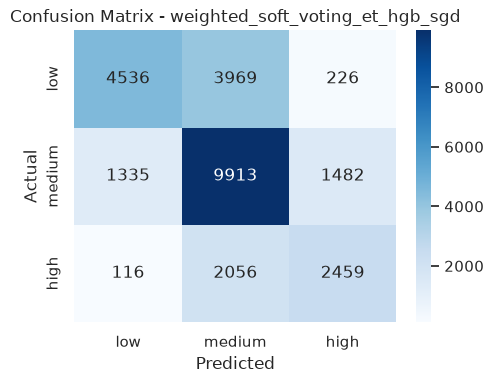

Metrics supervised:
method: weighted_soft_voting_et_hgb_sgd
model: weighted_soft_voting_et_hgb_sgd
task: no_leakage_prediction
rows_train: 13893
rows_evaluated: 26092
uses_outcome_metrics: False
leakage_safe_for_prediction: True
baseline_accuracy: 0.17748735244519392
accuracy: 0.6480147171546834
balanced_accuracy: 0.6097422169110607
f1_macro: 0.6223170869697845
f1_weighted: 0.6428824175895921
macro_f1: 0.6223170869697845
selection_score: 0.6266913403451762
target_accuracy: 0.8
target_reached: False
video_id_overlap: 0
features: ['title_text', 'title_len', 'title_word_count', 'title_upper_ratio', 'title_digit_count', 'title_exclaim_count', 'title_question_count', 'title_pipe_count', 'title_colon_count', 'title_hash_count', 'title_has_shorts', 'title_has_official', 'publish_hour', 'publish_dayofweek', 'publish_month', 'publish_dayofyear', 'is_weekend', 'publish_hour_sin', 'publish_hour_cos', 'publish_dow_sin', 'publish_dow_cos', 'channel', 'country', 'channel_country']


In [8]:
best_result = max(candidate_results, key=lambda item: item["metrics"]["accuracy"])
best_pred = best_result["pred"]

supervised_predictions_df = pd.DataFrame({
    video_id_col: model_df.loc[X_test.index][video_id_col].astype(str).to_numpy(),
    "actual_engagement_class": y_test.to_numpy(),
    "supervised_pred": best_pred,
})
supervised_predictions_df["supervised_correct"] = (
    supervised_predictions_df["actual_engagement_class"] == supervised_predictions_df["supervised_pred"]
)

print("\nBest no-leakage model by accuracy:", best_result["model"])
print("Target accuracy:", target_accuracy)
print("Target status:", "TERCAPAI" if best_result["metrics"]["accuracy"] >= target_accuracy else "BELUM TERCAPAI")
print("Catatan: target 80% belum boleh dikejar dengan views/likes/comments/engagement_rate/fetch_date/video_id sebagai fitur.")

labels = ["low", "medium", "high"]
cm = confusion_matrix(y_test, best_pred, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_result['model']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

metrics_supervised = {
    "method": best_result["model"],
    "model": best_result["model"],
    "task": "no_leakage_prediction",
    "rows_train": len(X_train_balanced),
    "rows_evaluated": len(X_test),
    "uses_outcome_metrics": False,
    "leakage_safe_for_prediction": True,
    "baseline_accuracy": accuracy_score(y_test, baseline_pred),
    **best_result["metrics"],
    "target_accuracy": target_accuracy,
    "target_reached": best_result["metrics"]["accuracy"] >= target_accuracy,
    "video_id_overlap": video_overlap,
    "features": feature_cols,
}

print("Metrics supervised:")
for key, value in metrics_supervised.items():
    print(f"{key}: {value}")


# Pengujian Model Supervised pada Data Baru di Luar Dataset (Out-of-Dataset Testing)

### Penjelasan Lengkap & Tujuan
Skenario ini melabeli data video nyata yang asli dari file CSV yang dikeluarkan di awal (Cell 4) untuk menguji seberapa baik model memprediksi video baru.

In [9]:
# Simulasi Pengujian Data Baru di Luar Dataset Menggunakan Data Asli Eksternal

# 1. Ambil data asli eksternal yang telah dipisahkan di awal (Cell 4)
df_new_sup = df_external_test.copy()

# 2. Ambil objek pipeline model terbaik hasil training
best_model_pipeline = best_result["estimator"]
best_model_name = best_result["model"]

# 3. Siapkan fitur input untuk data baru (sesuai feature_cols)
if title_col in df_new_sup.columns:
    df_new_sup["title_text"] = df_new_sup[title_col].fillna("").astype(str)
    df_new_sup["title_len"] = df_new_sup["title_text"].str.len()
    df_new_sup["title_word_count"] = df_new_sup["title_text"].str.split().str.len().fillna(0)
    df_new_sup["title_upper_ratio"] = df_new_sup["title_text"].str.count(r"[A-Z]").div(df_new_sup["title_len"].clip(lower=1))
    df_new_sup["title_digit_count"] = df_new_sup["title_text"].str.count(r"\d")
    df_new_sup["title_exclaim_count"] = df_new_sup["title_text"].str.count("!")
    df_new_sup["title_question_count"] = df_new_sup["title_text"].str.count(r"\?")
    df_new_sup["title_pipe_count"] = df_new_sup["title_text"].str.contains(r"\|").astype(int)
    df_new_sup["title_colon_count"] = df_new_sup["title_text"].str.contains(":").astype(int)
    df_new_sup["title_hash_count"] = df_new_sup["title_text"].str.count("#")
    df_new_sup["title_has_shorts"] = df_new_sup["title_text"].str.contains(
        r"(?i)#shorts|\bshorts\b", regex=True
    ).astype(int)
    df_new_sup["title_has_official"] = df_new_sup["title_text"].str.contains(
        r"(?i)official|trailer|music video|\bmv\b", regex=True
    ).astype(int)

if channel_col in df_new_sup.columns:
    df_new_sup["channel"] = df_new_sup[channel_col].fillna("unknown").astype(str)

if country_col in df_new_sup.columns:
    df_new_sup["country"] = df_new_sup[country_col].fillna("unknown").astype(str)

if {"channel", "country"}.issubset(df_new_sup.columns):
    df_new_sup["channel_country"] = df_new_sup["channel"] + "__" + df_new_sup["country"]

if _date_col and _date_col in df_new_sup.columns:
    df_new_sup["_dt"] = pd.to_datetime(df_new_sup[_date_col], errors="coerce", utc=True)
    df_new_sup["_dt"] = df_new_sup["_dt"].dt.tz_localize(None)
    df_new_sup["publish_hour"] = df_new_sup["_dt"].dt.hour.fillna(0).astype(int)
    df_new_sup["publish_dayofweek"] = df_new_sup["_dt"].dt.dayofweek.fillna(0).astype(int)
    df_new_sup["publish_month"] = df_new_sup["_dt"].dt.month.fillna(0).astype(int)
    df_new_sup["publish_dayofyear"] = df_new_sup["_dt"].dt.dayofyear.fillna(0).astype(int)
    df_new_sup["is_weekend"] = df_new_sup["publish_dayofweek"].isin([5, 6]).astype(int)
    df_new_sup["publish_hour_sin"] = np.sin(2 * np.pi * df_new_sup["publish_hour"] / 24)
    df_new_sup["publish_hour_cos"] = np.cos(2 * np.pi * df_new_sup["publish_hour"] / 24)
    df_new_sup["publish_dow_sin"] = np.sin(2 * np.pi * df_new_sup["publish_dayofweek"] / 7)
    df_new_sup["publish_dow_cos"] = np.cos(2 * np.pi * df_new_sup["publish_dayofweek"] / 7)

X_new_sup = df_new_sup[feature_cols]

# 4. Prediksi dengan Model Pipeline Terlatih / Ensemble
if best_model_pipeline is not None:
    preds_new = best_model_pipeline.predict(X_new_sup)
else:
    proba_blocks_new = []
    for name, clf, ensemble_weight in candidate_specs:
        if hasattr(clf, "predict_proba"):
            proba_blocks_new.append((ensemble_weight, clf.predict_proba(X_new_sup)))
    
    total_weight = sum(weight for weight, _ in proba_blocks_new)
    ensemble_proba_new = sum(weight * proba for weight, proba in proba_blocks_new) / total_weight
    preds_new = ensemble_classes[ensemble_proba_new.argmax(axis=1)]

# 5. Tampilkan hasil prediksi
df_new_sup["predicted_class"] = preds_new

print(f"Hasil Prediksi Supervised Model ({best_model_name}) pada Video Nyata di Luar Dataset:")
cols_show = [c for c in ["video_id", "title", "channel", "engagement_class", "predicted_class"] if c in df_new_sup.columns]

# Gunakan display dengan aman di terminal
try:
    display(df_new_sup[cols_show])
except NameError:
    print(df_new_sup[cols_show].to_string(index=False))


Hasil Prediksi Supervised Model (weighted_soft_voting_et_hgb_sgd) pada Video Nyata di Luar Dataset:


,video_id,title,channel,predicted_class
0,5kxvvh_znjY,Crystal Palace v Aston Villa | Key Moments | S...,The Emirates FA Cup,low
1,E0GvIwtIYGo,Trump zabrania wychodzenia z systemu dolaroweg...,Strategy&Future,medium
2,oXzjaCjxcIs,تحديت محمد عدنان في تحدي كروي مجنووون 🤯⚽ | تحد...,فياض الكندي | Fayadh Al-kindi,medium
3,XjCkk4VqbUY,MarvinVlogt vs. LAMBO?! 🏎️🤿,offen un' ehrlich,medium
4,oyaNTkYtDM8,The Taste of Kindness🥬🍣❣️,ISSEI / いっせい,high
5,9AL1oyQgKIM,"Eşref Rüya 5. Bölüm 1. Fragmanı | ""Sesinde Büy...",Eşref Rüya,medium
6,BhL8fjAUyTM,Bogdan DLP - Afacere 💸 Official Video,Bogdan DLP,low
7,-mB9-ItebUE,Sindhu Bairavi Kacheri Arambam | 12th & 13th J...,Vijay Television,low
8,HJlgtVLrfTE,RIP Dark JJ's Sister Squid Game Trap - MAIZEN ...,Mine Monster,medium
9,oO9RIXjhIEI,If fan could speak their feelings 💔😭most viral...,Bihari Ladka,medium


In [10]:
# Simpan model supervised terbaik ke file PKL
from pathlib import Path
import pickle

model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)
supervised_model_path = model_dir / "supervised_model.pkl"

candidate_estimators = {name: clf for name, clf, _ in candidate_specs}
candidate_weights = {name: ensemble_weight for name, _, ensemble_weight in candidate_specs}

supervised_model_artifact = {
    "task": "supervised_engagement_classification",
    "model_name": best_result["model"],
    "best_estimator": best_result["estimator"],
    "candidate_estimators": candidate_estimators,
    "candidate_weights": candidate_weights,
    "ensemble_classes": ensemble_classes,
    "feature_cols": feature_cols,
    "metrics": best_result["metrics"],
    "target_accuracy": target_accuracy,
    "label_order": ["low", "medium", "high"],
    "column_metadata": {
        "title_col": title_col,
        "channel_col": channel_col,
        "country_col": country_col,
        "video_id_col": video_id_col,
        "date_col": _date_col,
    },
}

with supervised_model_path.open("wb") as f:
    pickle.dump(supervised_model_artifact, f)

print(f"Model supervised disimpan ke: {supervised_model_path.resolve()}")


Model supervised disimpan ke: /root/machine_learning/models/supervised_model.pkl
